# Classification Problem

## Library Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

## Data Import

The data was taken from the ["Don't Get Kicked!"](https://www.kaggle.com/competitions/DontGetKicked/) competition

In [2]:
df = pd.read_csv('data/training.csv')
df.head()

,RefId,IsBadBuy,PurchDate,Auction,VehYear,VehicleAge,Make,Model,Trim,SubModel,...,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,PRIMEUNIT,AUCGUART,BYRNO,VNZIP1,VNST,VehBCost,IsOnlineSale,WarrantyCost
0,1,0,12/7/2009,ADESA,2006,3,MAZDA,MAZDA3,i,4D SEDAN I,...,11597.0,12409.0,NaN,NaN,21973,33619,FL,7100.0,0,1113
1,2,0,12/7/2009,ADESA,2004,5,DODGE,1500 RAM PICKUP 2WD,ST,QUAD CAB 4.7L SLT,...,11374.0,12791.0,NaN,NaN,19638,33619,FL,7600.0,0,1053
2,3,0,12/7/2009,ADESA,2005,4,DODGE,STRATUS V6,SXT,4D SEDAN SXT FFV,...,7146.0,8702.0,NaN,NaN,19638,33619,FL,4900.0,0,1389
3,4,0,12/7/2009,ADESA,2004,5,DODGE,NEON,SXT,4D SEDAN,...,4375.0,5518.0,NaN,NaN,19638,33619,FL,4100.0,0,630
4,5,0,12/7/2009,ADESA,2005,4,FORD,FOCUS,ZX3,2D COUPE ZX3,...,6739.0,7911.0,NaN,NaN,19638,33619,FL,4000.0,0,1020


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72983 entries, 0 to 72982
Data columns (total 34 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   RefId                              72983 non-null  int64  
 1   IsBadBuy                           72983 non-null  int64  
 2   PurchDate                          72983 non-null  str    
 3   Auction                            72983 non-null  str    
 4   VehYear                            72983 non-null  int64  
 5   VehicleAge                         72983 non-null  int64  
 6   Make                               72983 non-null  str    
 7   Model                              72983 non-null  str    
 8   Trim                               70623 non-null  str    
 9   SubModel                           72975 non-null  str    
 10  Color                              72975 non-null  str    
 11  Transmission                       72974 non-null  str    
 12  W

In [4]:
df.shape

(72983, 34)

In [5]:
df_preprocessed = df.copy()

# Drop index column
df_preprocessed = df_preprocessed.drop('RefId', axis=1)

In [6]:
# Transform `PurchDate` to datetime and sort by it
df_preprocessed['PurchDate'] = pd.to_datetime(df_preprocessed['PurchDate'], format='%m/%d/%Y')
df_preprocessed = df_preprocessed.sort_values(by='PurchDate')

## EDA

### NaNs research

In [7]:
# Look at the NaNs percentage in the columns
missing_percent = df_preprocessed.isna().mean() * 100
missing_with_data = missing_percent[missing_percent > 0]
missing_with_data.sort_values(ascending=False)

AUCGUART                             95.315347
PRIMEUNIT                            95.315347
WheelType                             4.348958
WheelTypeID                           4.342107
Trim                                  3.233630
MMRCurrentAuctionAveragePrice         0.431607
MMRCurrentAuctionCleanPrice           0.431607
MMRCurrentRetailAveragePrice          0.431607
MMRCurrentRetailCleanPrice            0.431607
MMRAcquisitionAuctionCleanPrice       0.024663
MMRAcquisitionAuctionAveragePrice     0.024663
MMRAcquisitionRetailAveragePrice      0.024663
MMRAcquisitonRetailCleanPrice         0.024663
Transmission                          0.012332
SubModel                              0.010961
Color                                 0.010961
Size                                  0.006851
Nationality                           0.006851
TopThreeAmericanName                  0.006851
dtype: float64

### MMR features research

In [8]:
# There is a lot of MMR cols. Look at the them in a more detailed way
MMR_cols = list(filter(lambda x: x.startswith('MMR'), df_preprocessed.columns))
df_preprocessed[MMR_cols].corr(numeric_only=True)

,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice
MMRAcquisitionAuctionAveragePrice,1.000000,0.990347,0.910391,0.910187,0.937817,0.932492,0.871755,0.871042
MMRAcquisitionAuctionCleanPrice,0.990347,1.000000,0.902718,0.918242,0.923610,0.932114,0.860716,0.871203
MMRAcquisitionRetailAveragePrice,0.910391,0.902718,1.000000,0.990201,0.851647,0.849407,0.913108,0.906054
MMRAcquisitonRetailCleanPrice,0.910187,0.918242,0.990201,1.000000,0.846914,0.855689,0.903188,0.906810
MMRCurrentAuctionAveragePrice,0.937817,0.923610,0.851647,0.846914,1.000000,0.990329,0.915073,0.912231
MMRCurrentAuctionCleanPrice,0.932492,0.932114,0.849407,0.855689,0.990329,1.000000,0.908669,0.921536
MMRCurrentRetailAveragePrice,0.871755,0.860716,0.913108,0.903188,0.915073,0.908669,1.000000,0.989760
MMRCurrentRetailCleanPrice,0.871042,0.871203,0.906054,0.906810,0.912231,0.921536,0.989760,1.000000


All of them are quite correlated

#### Values Counts

In [9]:
df_preprocessed['WheelType'].value_counts()

WheelType
Alloy      36050
Covers     33004
Special      755
Name: count, dtype: int64

In [10]:
df_preprocessed['WheelTypeID'].value_counts()

WheelTypeID
1.0    36050
2.0    33004
3.0      755
0.0        5
Name: count, dtype: int64

In [11]:
df_preprocessed['Trim'].value_counts()

Trim
Bas    13950
LS     10174
SE      9348
SXT     3825
LT      3540
       ...  
LL         1
Maz        1
Out        1
JLX        1
Z24        1
Name: count, Length: 134, dtype: int64

In [12]:
df_preprocessed['Size'].value_counts()

Size
MEDIUM         30785
LARGE           8850
MEDIUM SUV      8090
COMPACT         7205
VAN             5854
LARGE TRUCK     3170
SMALL SUV       2276
SPECIALTY       1915
CROSSOVER       1759
LARGE SUV       1433
SMALL TRUCK      864
SPORTS           777
Name: count, dtype: int64

In [13]:
df_preprocessed['TopThreeAmericanName'].value_counts()

TopThreeAmericanName
GM          25314
CHRYSLER    23399
FORD        12315
OTHER       11950
Name: count, dtype: int64

In [14]:
df_preprocessed['Nationality'].value_counts()

Nationality
AMERICAN          61028
OTHER ASIAN        8033
TOP LINE ASIAN     3722
OTHER               195
Name: count, dtype: int64

In [15]:
df_preprocessed['Transmission'].value_counts()

Transmission
AUTO      70398
MANUAL     2575
Manual        1
Name: count, dtype: int64

## Data Preprocessing

### Features dropping

In [16]:
# As was researched before all MMR features are quite correlated.
# Will use only one of them: `MMRAcquisitionRetailAveragePrice`.
# This will also solve the problem with NaNs in all columns starting with MMR string

MMR_to_drop = ['MMRAcquisitionAuctionAveragePrice', 'MMRAcquisitionAuctionCleanPrice', 'MMRAcquisitonRetailCleanPrice',
               'MMRCurrentAuctionAveragePrice', 'MMRCurrentAuctionCleanPrice', 'MMRCurrentRetailAveragePrice', 'MMRCurrentRetailCleanPrice']
df_preprocessed = df_preprocessed.drop(MMR_to_drop, axis=1)

In [17]:
# Drop features `AUCGUART` and `PRIMEUNIT`. Most of theirs values are NaNs
df_preprocessed = df_preprocessed.drop(['PRIMEUNIT', 'AUCGUART'], axis=1)

### Values replacement

In [18]:
# Also change `Manual` into `MANUAL` value in `Transmission` column. Prhaps error in data and won't be leakage
df_preprocessed['Transmission'] = df_preprocessed['Transmission'].replace({'Manual': 'MANUAL'})

In [19]:
# 'Trim' feature has many single values. Change their category on 'other'
min_count = 100
small_categories = df_preprocessed['Trim'].value_counts()[df_preprocessed['Trim'].value_counts() < min_count].index
df_preprocessed['Trim'] = df_preprocessed['Trim'].replace(small_categories, 'Other')

df_preprocessed['Trim'].value_counts()

Trim
Bas      13950
LS       10174
SE        9348
SXT       3825
LT        3540
LX        2417
Tou       2256
EX        2120
Other     1819
SEL       1360
XLT       1357
GLS       1355
Spo       1254
SLT       1200
Lim        965
Lar        902
ST         841
GT         808
XLS        772
2          765
ES         700
S          630
ZX4        606
SES        601
LE         572
SLE        543
i          487
Cla        475
Nor        448
XL         448
GL         410
150        305
Cus        299
GS         295
STX        288
ZX3        246
CX         230
Adv        227
CE         221
Edd        213
s          212
XE         206
3          188
1          168
L30        141
L20        115
LXi        111
Edg        108
W/T        102
Name: count, dtype: int64

### Train/validate/test splitting

In [20]:
# Make splitting by `PurchDate` column.
# Use the first 1/3 of dates for the train, the last 1/3 of dates for the test, and the middle 1/3 for the validation set

date_33_perc, date_66_perc = df_preprocessed['PurchDate'].quantile(0.33), df_preprocessed['PurchDate'].quantile(0.66)

df_train, df_validate, df_test = (df_preprocessed[df_preprocessed['PurchDate'] <= date_33_perc].reset_index(drop=True),
                                  df_preprocessed[(df_preprocessed['PurchDate'] > date_33_perc) & (df_preprocessed['PurchDate'] <= date_66_perc)].reset_index(drop=True),
                                  df_preprocessed[df_preprocessed['PurchDate'] > date_66_perc].reset_index(drop=True))

In [21]:
print(f'Train data length: {len(df_train)}')
print(f'Validation data length: {len(df_validate)}')
print(f'Test data length: {len(df_test)}')
print('==========================')
print(f'Train data min `PurchDate`: {df_train['PurchDate'].min()}; Train data max `PurchDate`: {df_train['PurchDate'].max()}')
print(f'Validation data min `PurchDate`: {df_validate['PurchDate'].min()}; Validation data max `PurchDate`: {df_validate['PurchDate'].max()}')
print(f'Test data min `PurchDate`: {df_test['PurchDate'].min()}; Test data max `PurchDate`: {df_test['PurchDate'].max()}')

Train data length: 24143
Validation data length: 24094
Test data length: 24746
Train data min `PurchDate`: 2009-01-05 00:00:00; Train data max `PurchDate`: 2009-09-11 00:00:00
Validation data min `PurchDate`: 2009-09-14 00:00:00; Validation data max `PurchDate`: 2010-05-11 00:00:00
Test data min `PurchDate`: 2010-05-12 00:00:00; Test data max `PurchDate`: 2010-12-30 00:00:00


### NaNs fullfilling

In [22]:
def ultimate_nan_fullfill(df):
    '''
    Fill with the most common value from train samples
    '''
    df_to_transform = df.copy()
    
    df_to_transform['WheelType'] = df_to_transform['WheelType'].fillna(df_train['WheelType'].mode()[0])
    df_to_transform['WheelTypeID'] = df_to_transform['WheelTypeID'].fillna(df_train['WheelTypeID'].mode()[0])
    df_to_transform['Trim'] = df_to_transform['Trim'].fillna(df_train['Trim'].mode()[0])
    df_to_transform['Size'] = df_to_transform['Size'].fillna(df_train['Size'].mode()[0])
    df_to_transform['TopThreeAmericanName'] = df_to_transform['TopThreeAmericanName'].fillna(df_train['TopThreeAmericanName'].mode()[0])
    df_to_transform['Nationality'] = df_to_transform['Nationality'].fillna(df_train['Nationality'].mode()[0])
    df_to_transform['Transmission'] = df_to_transform['Transmission'].fillna(df_train['Transmission'].mode()[0])
    
    df_to_transform['Color'] = df_to_transform['Color'].fillna(df_train['Color'].mode()[0])
    df_to_transform['SubModel'] = df_to_transform['SubModel'].fillna(df_train['SubModel'].mode()[0])
    df_to_transform['MMRAcquisitionRetailAveragePrice'] = df_to_transform['MMRAcquisitionRetailAveragePrice'].fillna(df_train['MMRAcquisitionRetailAveragePrice'].mode()[0])
    
    return df_to_transform

In [23]:
df_train = ultimate_nan_fullfill(df_train)
df_validate = ultimate_nan_fullfill(df_validate)
df_test = ultimate_nan_fullfill(df_test)

In [24]:
# Calculate NaNs count by columns
print(f'Train: {df_train.isna().sum().sum()}')
print(f'Validation: {df_validate.isna().sum().sum()}')
print(f'Test: {df_test.isna().sum().sum()}')

Train: 0
Validation: 0
Test: 0


###  Turning 'str' into 'category' dtype

In [25]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 24143 entries, 0 to 24142
Data columns (total 24 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   IsBadBuy                          24143 non-null  int64         
 1   PurchDate                         24143 non-null  datetime64[us]
 2   Auction                           24143 non-null  str           
 3   VehYear                           24143 non-null  int64         
 4   VehicleAge                        24143 non-null  int64         
 5   Make                              24143 non-null  str           
 6   Model                             24143 non-null  str           
 7   Trim                              24143 non-null  str           
 8   SubModel                          24143 non-null  str           
 9   Color                             24143 non-null  str           
 10  Transmission                      24143 non-null  str    

In [26]:
cols_with_str_dtype = df_train.select_dtypes(include='str').columns

df_train[cols_with_str_dtype] = df_train[cols_with_str_dtype].astype('category')
df_validate[cols_with_str_dtype] = df_validate[cols_with_str_dtype].astype('category')
df_test[cols_with_str_dtype] = df_test[cols_with_str_dtype].astype('category')

In [27]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 24143 entries, 0 to 24142
Data columns (total 24 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   IsBadBuy                          24143 non-null  int64         
 1   PurchDate                         24143 non-null  datetime64[us]
 2   Auction                           24143 non-null  category      
 3   VehYear                           24143 non-null  int64         
 4   VehicleAge                        24143 non-null  int64         
 5   Make                              24143 non-null  category      
 6   Model                             24143 non-null  category      
 7   Trim                              24143 non-null  category      
 8   SubModel                          24143 non-null  category      
 9   Color                             24143 non-null  category      
 10  Transmission                      24143 non-null  categor

### One-Hot Encoding and Count Encoding

Will use One-Hot Encoding for columns: `Auction`, `Transmission`, `WheelType`, `Nationality`, `TopThreeAmericanName`

Will use Count Encoding for columns: `Make`, `Model`, `Trim`, `SubModel`, `Color`, `Size`, `VNST` because of their large amount of possible and rare values

In [28]:
from sklearn.preprocessing import OneHotEncoder
from category_encoders.count import CountEncoder

In [29]:
# Cols for encoding
cols_to_count_encode = ['Make', 'Model', 'Trim', 'SubModel', 'Color', 'Size', 'VNST']
cols_to_onehot_encode = ['Auction', 'Transmission', 'WheelType', 'Nationality', 'TopThreeAmericanName']

In [30]:
count_encoder = CountEncoder(cols=cols_to_count_encode, handle_unknown=-1)

onehot_encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False,
    dtype=int
)

Count Encoder application

In [31]:
# Apply Count Encoder
df_train_encoded = count_encoder.fit_transform(df_train)
df_validate_encoded = count_encoder.transform(df_validate)
df_test_encoded = count_encoder.transform(df_test)

One-Hot-Encoder Encoder application

In [32]:
def auto_onehot_encoder(cols_to_onehot_encode,
                        df_to_train, df_to_transform
                        ):
    """
    Function for automatic One-Hot Encoding
    """
    # Fit on train data
    onehot_encoder.fit(df_to_train[cols_to_onehot_encode])

    # Get all possible categories
    all_categories = []
    for i, col in enumerate(cols_to_onehot_encode):
        categories = onehot_encoder.categories_[i]
        all_categories.extend([f"{col}_{cat}" for cat in categories])

    # Function to transform with all cols keeping
    encoded = onehot_encoder.transform(df_to_transform[cols_to_onehot_encode])
    df_encoded = pd.DataFrame(encoded, columns=onehot_encoder.get_feature_names_out(cols_to_onehot_encode))

    # Add missing cols (for new categories)
    for col in all_categories:
        if col not in df_encoded.columns:
            df_encoded[col] = 0

    # Concat new cols and drop old
    df_transformed = pd.concat([df_to_transform, df_encoded], axis=1)
    df_transformed = df_transformed.drop(cols_to_onehot_encode, axis=1)
    
    return df_transformed

In [33]:
df_train_encoded = auto_onehot_encoder(cols_to_onehot_encode, df_train, df_train_encoded)
df_validate_encoded = auto_onehot_encoder(cols_to_onehot_encode, df_train, df_validate_encoded)
df_test_encoded = auto_onehot_encoder(cols_to_onehot_encode, df_train, df_test_encoded)

In [34]:
# Compare the new the dfs' shapes
print(f'df_train shape: {df_train.shape}')
print(f'df_validate shape: {df_validate.shape}')
print(f'df_test shape: {df_test.shape}')
print('=================================')
print(f'df_train_encoded shape: {df_train_encoded.shape}')
print(f'df_validate_encoded shape: {df_validate_encoded.shape}')
print(f'df_test_encoded shape: {df_test_encoded.shape}')

df_train shape: (24143, 24)
df_validate shape: (24094, 24)
df_test shape: (24746, 24)
df_train_encoded shape: (24143, 35)
df_validate_encoded shape: (24094, 35)
df_test_encoded shape: (24746, 35)


### X/y splitting

In [35]:
X_train_encoded = df_train_encoded.drop(['IsBadBuy', 'PurchDate'], axis=1)
X_validate_encoded = df_validate_encoded.drop(['IsBadBuy', 'PurchDate'], axis=1)
X_test_encoded = df_test_encoded.drop(['IsBadBuy', 'PurchDate'], axis=1)

In [36]:
X_train_with_cats = df_train.drop(['IsBadBuy', 'PurchDate'], axis=1)
X_validate_with_cats = df_validate.drop(['IsBadBuy', 'PurchDate'], axis=1)
X_test_with_cats = df_test.drop(['IsBadBuy', 'PurchDate'], axis=1)

In [37]:
y_train = df_train['IsBadBuy']
y_validate = df_validate['IsBadBuy']
y_test = df_test['IsBadBuy']

### Normalization

Apply normalization to the new features

In [38]:
from sklearn.preprocessing import StandardScaler

In [39]:
# With encoded categorical features

scaler = StandardScaler()
X_train_encoded_scaled = pd.DataFrame(scaler.fit_transform(X_train_encoded), columns=X_train_encoded.columns)
X_validate_encoded_scaled = pd.DataFrame(scaler.transform(X_validate_encoded), columns=X_validate_encoded.columns)
X_test_encoded_scaled = pd.DataFrame(scaler.transform(X_test_encoded), columns=X_test_encoded.columns)

In [40]:
# With non-encoded categorical features

noncategorical_cols = X_train_with_cats.select_dtypes(['int64', 'float64']).columns
categorical_cols = X_train_with_cats.select_dtypes('category').columns

nonencoded_scaler = StandardScaler()
nonencoded_scaler.fit(X_train_with_cats[noncategorical_cols])

def df_with_cats_scaler(df):
    """
    Implement StandardScaler only to numeric cols ignoring categorical ones. Returns transformed pd.DataFrame
    """
    cat_cols = df[categorical_cols]
    num_cols = pd.DataFrame(nonencoded_scaler.transform(df[noncategorical_cols]), columns=noncategorical_cols)
    
    return pd.concat([cat_cols, num_cols], axis=1)

X_train_with_cats_scaled = df_with_cats_scaler(X_train_with_cats)
X_validate_with_cats_scaled = df_with_cats_scaler(X_validate_with_cats)
X_test_with_cats_scaled = df_with_cats_scaler(X_test_with_cats)

## Scikit-learn models

Train sklearn models (`Logistic Regression`, `KNN` and `Naive Bayes`), plot the ROC curve and find the AUC scores for future comparing with custom implementations and the scores after feature engineering

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

from modules.classification_metrics import custom_roc_auc_score, custom_gini_coefficient

In [42]:
# DataFrame for future metrics results
df_sklearn_custom_metrics = pd.DataFrame(columns=['Model Name', 'AUC score', 'Gini Coef'])

In [43]:
def fit_predict_pipeline(X_train, y_train, X_validate, y_validate, model, model_name, metrics_df):
    """
    Function for fit/predict pipeline with printing metrics and ROC curve
    """
    cur_model = clone(model)
    cur_model.fit(X_train, y_train)
    proba_preds = cur_model.predict_proba(X_validate)[:, 1]
    
    auc_score = custom_roc_auc_score(y_validate, proba_preds, plot=True)
    gini_score = custom_gini_coefficient(y_validate, proba_preds)
    
    print(f'AUC score: {auc_score}')
    print(f'Gini coef: {gini_score}')
    metrics_df.loc[len(metrics_df)] = [model_name, auc_score, gini_score]

# def fit_predict_pipeline(X_train, y_train, X_validate, y_validate, model, model_name, metrics_df):
#     """
#     Function for fit/predict pipeline with printing metrics and ROC curve
#     """
#     if isinstance(X_train, pd.DataFrame):
#         X_train = X_train.values
#         X_validate = X_validate.values
    
#     if isinstance(y_train, (pd.Series, pd.DataFrame)):
#         y_train = y_train.values.ravel()
#         y_validate = y_validate.values.ravel()
#     elif isinstance(y_train, np.ndarray):
#         y_train = y_train.ravel()
#         y_validate = y_validate.ravel()
    
#     cur_model = clone(model)
#     cur_model.fit(X_train, y_train)
    
#     proba_preds = cur_model.predict_proba(X_validate)[:, 1]
    
#     auc_score = custom_roc_auc_score(y_validate, proba_preds, plot=True)
#     gini_score = custom_gini_coefficient(y_validate, proba_preds)
    
#     print(f'AUC score: {auc_score}')
#     print(f'Gini coef: {gini_score}')
#     metrics_df.loc[len(metrics_df)] = [model_name, auc_score, gini_score]

### Logistic Regression

AUC score: 0.6619543950680131
Gini coef: 0.32390879013602625


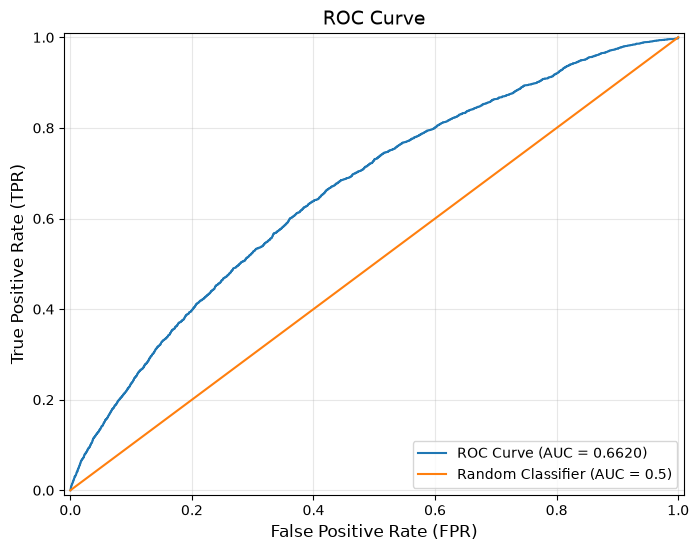

In [44]:
fit_predict_pipeline(X_train_encoded_scaled, y_train, X_validate_encoded_scaled, y_validate,
                     LogisticRegression(), 'Logistic Regression (One-Hot + Count Encoders)',
                     df_sklearn_custom_metrics)

### KNN

AUC score: 0.590997987212794
Gini coef: 0.1819959744255879


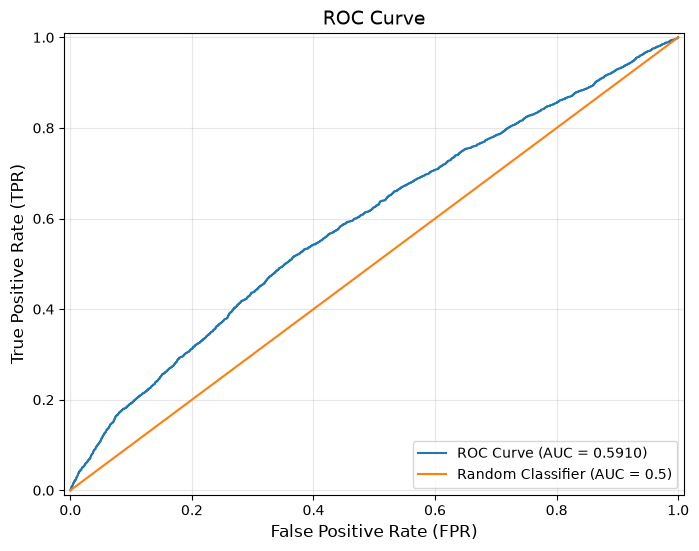

In [45]:
fit_predict_pipeline(X_train_encoded_scaled, y_train, X_validate_encoded_scaled, y_validate,
                     KNeighborsClassifier(), 'KNN (One-Hot + Count Encoders)',
                     df_sklearn_custom_metrics)

### Decision Tree

AUC score: 0.5524013542098314
Gini coef: 0.10480270841966277


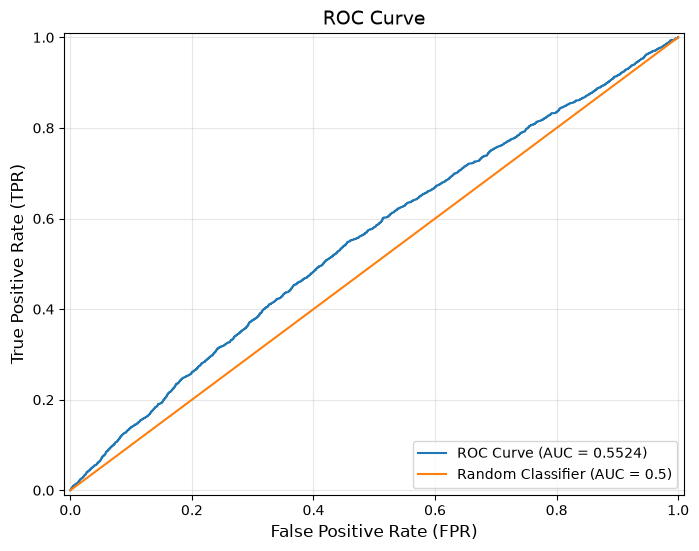

In [46]:
fit_predict_pipeline(X_train_encoded_scaled, y_train, X_validate_encoded_scaled, y_validate,
                     DecisionTreeClassifier(), 'Decision Tree (One-Hot + Count Encoders)',
                     df_sklearn_custom_metrics)

### Extra Randomized Tree

AUC score: 0.5548153949451355
Gini coef: 0.10963078989027109


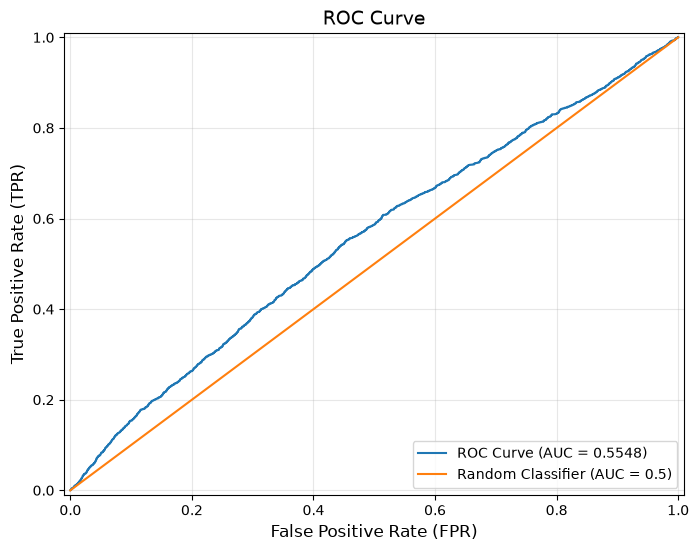

In [47]:
fit_predict_pipeline(X_train_encoded_scaled, y_train, X_validate_encoded_scaled, y_validate,
                     ExtraTreeClassifier(), 'Extra Randomized Tree (One-Hot + Count Encoders)',
                     df_sklearn_custom_metrics)

### Random Forest Classifier

AUC score: 0.6617197076132942
Gini coef: 0.3234394152265885


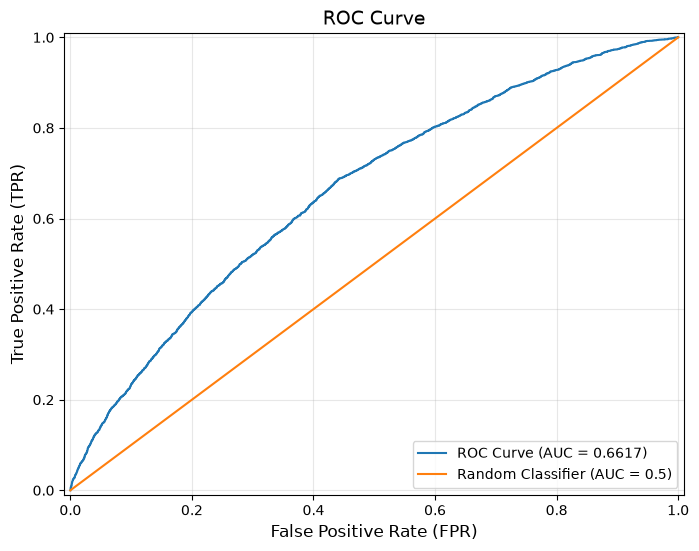

In [48]:
fit_predict_pipeline(X_train_encoded_scaled, y_train, X_validate_encoded_scaled, y_validate,
                     RandomForestClassifier(), 'Random Forest (One-Hot + Count Encoders)',
                     df_sklearn_custom_metrics)

## Boosting Ensembles

In [49]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

### XGBoost (with pre-encoded categorical features)

AUC score: 0.6405395552370127
Gini coef: 0.28107911047402534


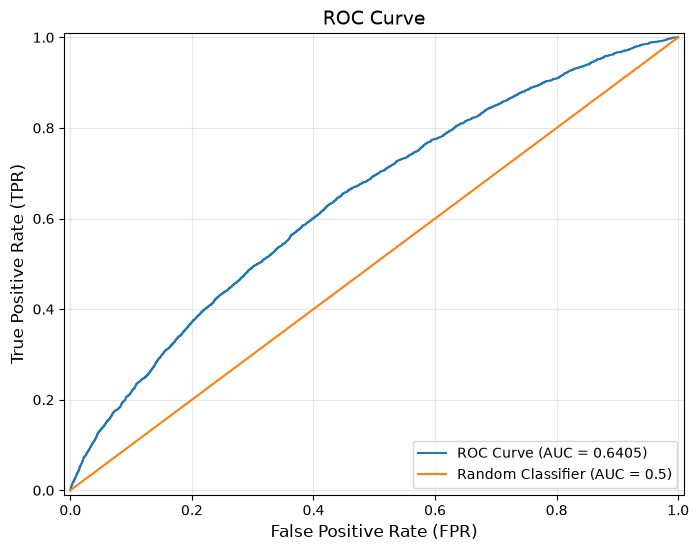

In [50]:
fit_predict_pipeline(X_train_encoded_scaled, y_train, X_validate_encoded_scaled, y_validate,
                     XGBClassifier(), 'XGBoost (One-Hot + Count Encoders)',
                     df_sklearn_custom_metrics)

### LightGBM (with pre-encoded categorical features)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 2771, number of negative: 21372
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002172 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1575
[LightGBM] [Info] Number of data points in the train set: 24143, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.114774 -> initscore=-2.042873
[LightGBM] [Info] Start training from score -2.042873
AUC score: 0.6676321060746668
Gini coef: 0.33526421214933366


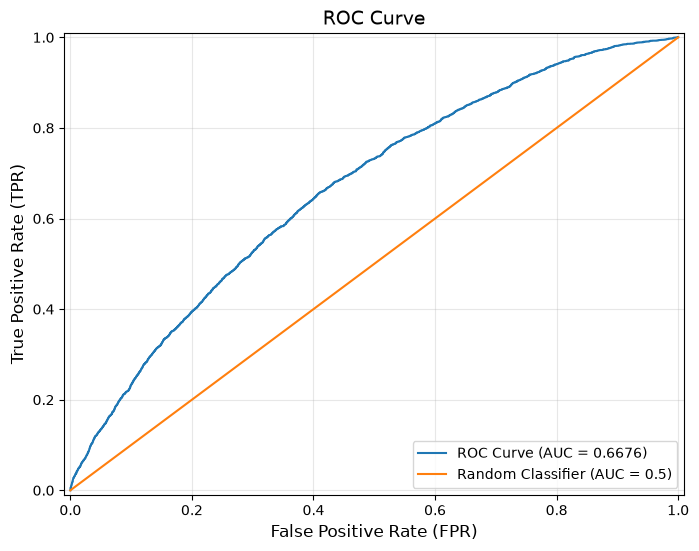

In [51]:
fit_predict_pipeline(X_train_encoded_scaled, y_train, X_validate_encoded_scaled, y_validate,
                     LGBMClassifier(), 'LightGBM (One-Hot + Count Encoders)',
                     df_sklearn_custom_metrics)

### CatBoost (with pre-encoded categorical features)

AUC score: 0.661376356485972
Gini coef: 0.3227527129719441


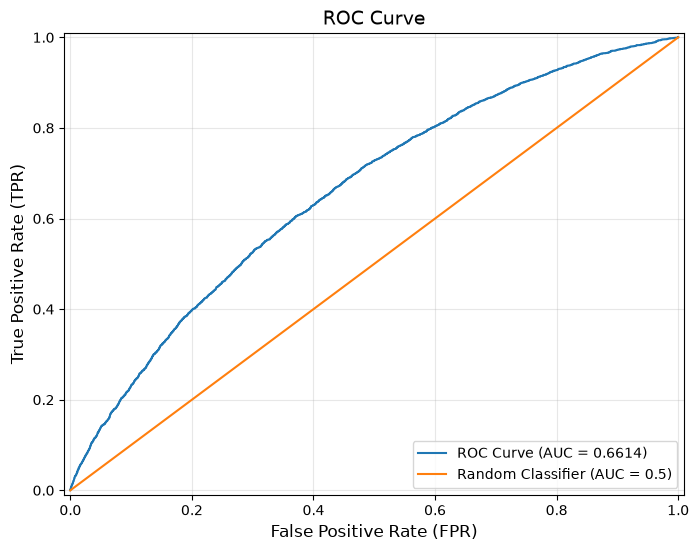

In [52]:
fit_predict_pipeline(X_train_encoded_scaled, y_train, X_validate_encoded_scaled, y_validate,
                     CatBoostClassifier(verbose=False), 'CatBoost (One-Hot + Count Encoders)',
                     df_sklearn_custom_metrics)

### CatBoost (without pre-encoded categorical features)

AUC score: 0.6798260592831871
Gini coef: 0.35965211856637413


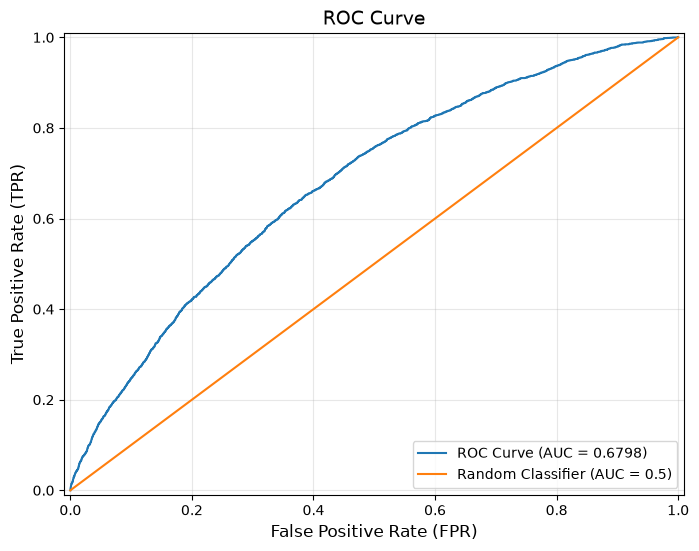

In [53]:
cat_cols = cols_to_count_encode + cols_to_onehot_encode

cat_boost_model = CatBoostClassifier(cat_features=cat_cols, verbose=False)

# Use the manual `fit_predict_pipeline` functionality because CatBoost loses its `cat_features` with sklearn.clone method
cat_boost_model.fit(X_train_with_cats_scaled, y_train)
proba_preds = cat_boost_model.predict_proba(X_validate_with_cats_scaled)[:, 1]
auc_score = custom_roc_auc_score(y_validate, proba_preds, plot=True)
gini_score = custom_gini_coefficient(y_validate, proba_preds)
print(f'AUC score: {auc_score}')
print(f'Gini coef: {gini_score}')
df_sklearn_custom_metrics.loc[len(df_sklearn_custom_metrics)] = ['CatBoost (df with non-encoded categorical)', auc_score, gini_score]

## Custom models' implementations

Now compare metrics values with custom impementations of `Logistic Regression`, `KNN` and `Naive Bayes`

In [54]:
from modules.logistic_regression import Custom_LogisticRegression
from modules.knn import Custom_KNeighborsClassifier
from modules.naive_bayes import Custom_NaiveBayes
from modules.tree import Custom_DecisionTreeClassifier
from modules.extra_randomized_tree import Custom_ExtraTreesClassifier
from modules.random_forest import Custom_RandomForestClassifier
from modules.gradient_boosting import Custom_GradientBoostingClassifier

### Logistic Regression

AUC score: 0.6618921867453235
Gini coef: 0.3237843734906469


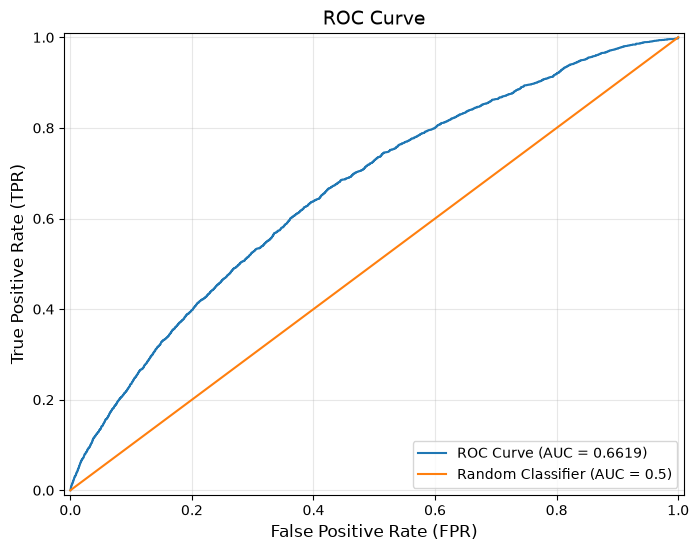

In [55]:
fit_predict_pipeline(X_train_encoded_scaled, y_train, X_validate_encoded_scaled, y_validate,
                     Custom_LogisticRegression(), 'Logistic Regression Custom (One-Hot + Count Encoders)',
                     df_sklearn_custom_metrics)

### KNN

AUC score: 0.590997987212794
Gini coef: 0.1819959744255879


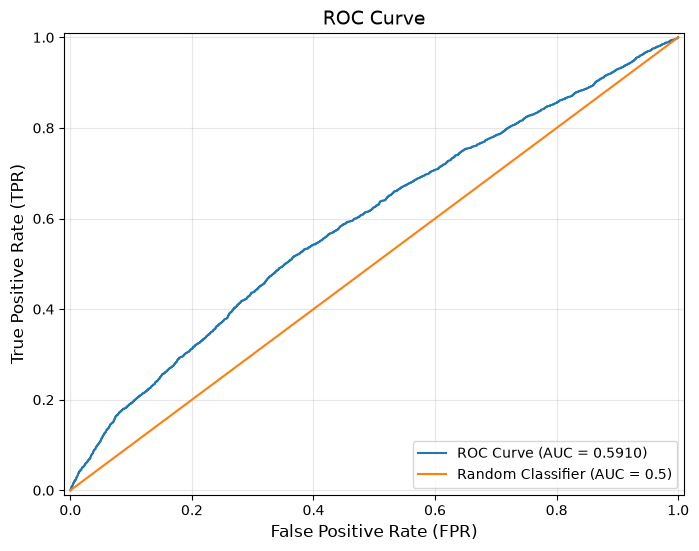

In [56]:
fit_predict_pipeline(X_train_encoded_scaled, y_train, X_validate_encoded_scaled, y_validate,
                     Custom_KNeighborsClassifier(), 'KNN Custom (One-Hot + Count Encoders)',
                     df_sklearn_custom_metrics)

### Decision Tree

AUC score: 0.5471517177297633
Gini coef: 0.09430343545952669


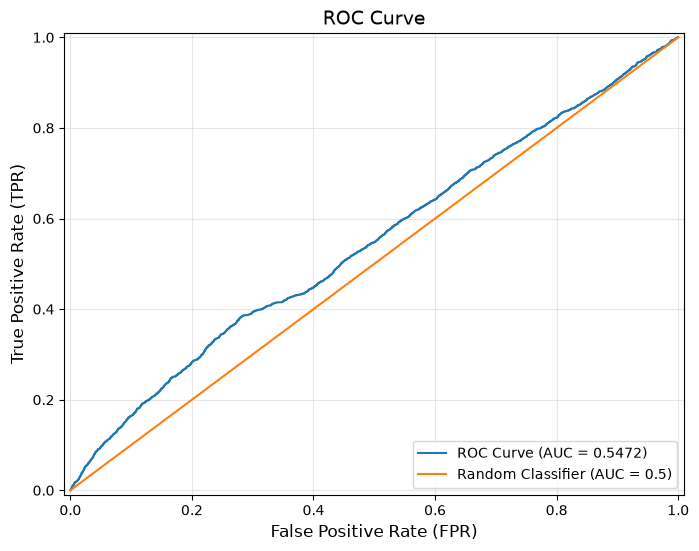

In [57]:
fit_predict_pipeline(X_train_encoded_scaled, y_train, X_validate_encoded_scaled, y_validate,
                     Custom_DecisionTreeClassifier(), 'Decision Tree Custom (One-Hot + Count Encoders)',
                     df_sklearn_custom_metrics)

### Extra Randomized Tree

AUC score: 0.6340118659759953
Gini coef: 0.2680237319519907


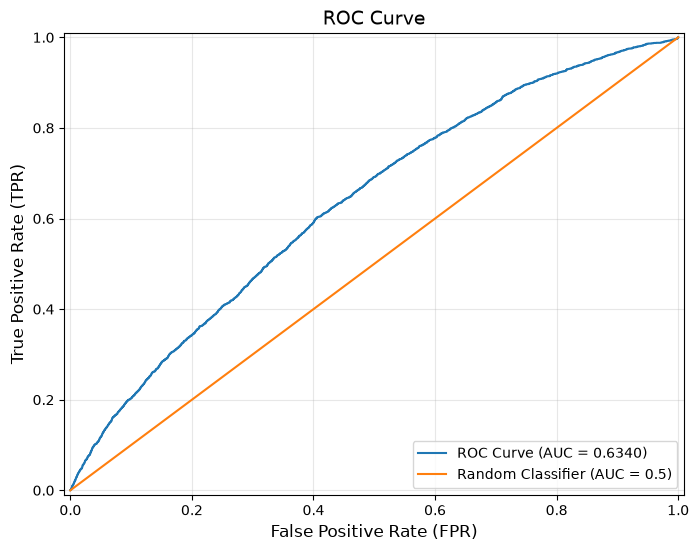

In [58]:
fit_predict_pipeline(X_train_encoded_scaled, y_train, X_validate_encoded_scaled, y_validate,
                     Custom_ExtraTreesClassifier(), 'Extra Randomized Tree Custom (One-Hot + Count Encoders)',
                     df_sklearn_custom_metrics)

### Random Forest

AUC score: 0.6353077792015454
Gini coef: 0.2706155584030907


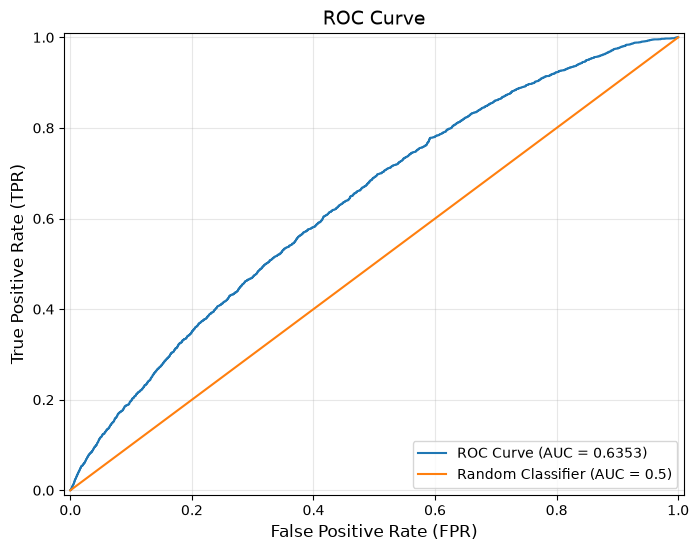

In [59]:
fit_predict_pipeline(X_train_encoded_scaled, y_train, X_validate_encoded_scaled, y_validate,
                     Custom_RandomForestClassifier(), 'Random Forest Custom (One-Hot + Count Encoders)',
                     df_sklearn_custom_metrics)

### Gradient Boosting

AUC score: 0.598404931908565
Gini coef: 0.19680986381713006


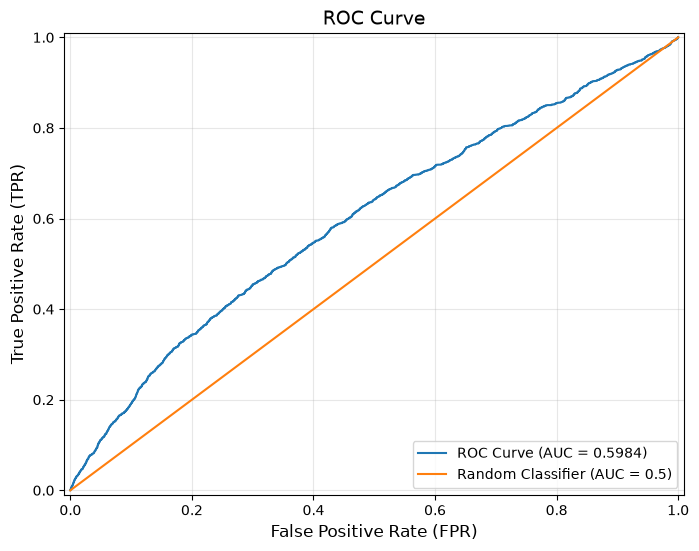

In [60]:
fit_predict_pipeline(X_train_encoded_scaled, y_train, X_validate_encoded_scaled, y_validate,
                     Custom_GradientBoostingClassifier(), 'Gradient Boosting Custom (One-Hot + Count Encoders)',
                     df_sklearn_custom_metrics)

## Scikit-learn and custom models comparison

In [61]:
df_sklearn_custom_metrics

,Model Name,AUC score,Gini Coef
0,Logistic Regression (One-Hot + Count Encoders),0.661954,0.323909
1,KNN (One-Hot + Count Encoders),0.590998,0.181996
2,Decision Tree (One-Hot + Count Encoders),0.552401,0.104803
3,Extra Randomized Tree (One-Hot + Count Encoders),0.554815,0.109631
4,Random Forest (One-Hot + Count Encoders),0.661720,0.323439
5,XGBoost (One-Hot + Count Encoders),0.640540,0.281079
6,LightGBM (One-Hot + Count Encoders),0.667632,0.335264
7,CatBoost (One-Hot + Count Encoders),0.661376,0.322753
8,CatBoost (df with non-encoded categorical),0.679826,0.359652
9,Logistic Regression Custom (One-Hot + Count En...,0.661892,0.323784


## GridSearch. Selecting the best model (algorithm + feature set)

In [62]:
from sklearn.model_selection import GridSearchCV

In [63]:
final_model = CatBoostClassifier(verbose=False, random_state=42,
                                 border_count=128, boost_from_average=True,
                                 depth=6)
grid = {
    'iterations': [300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'grow_policy': ['SymmetricTree', 'Lossguide', 'Depthwise']
}

gridsearch_model = GridSearchCV(param_grid=grid,
                                estimator=final_model,
                                cv=5)

gridsearch_model.fit(X_train_with_cats_scaled, y_train, cat_features=cat_cols)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",CatBoostClass...verbose=False)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'grow_policy': ['SymmetricTree', 'Lossguide', ...], 'iterations': [300, 500], 'learning_rate': [0.01, 0.05, ...]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbo

In [64]:
pd.set_option('display.max_colwidth', None)
pd.DataFrame(gridsearch_model.cv_results_)[['rank_test_score', 'mean_test_score', 'params']].sort_values(by='rank_test_score').head()

,rank_test_score,mean_test_score,params
12,1,0.885350,"{'grow_policy': 'Lossguide', 'iterations': 500, 'learning_rate': 0.01}"
9,2,0.885308,"{'grow_policy': 'Lossguide', 'iterations': 300, 'learning_rate': 0.05}"
20,3,0.885308,"{'grow_policy': 'Depthwise', 'iterations': 500, 'learning_rate': 0.01}"
0,4,0.885226,"{'grow_policy': 'SymmetricTree', 'iterations': 300, 'learning_rate': 0.01}"
8,4,0.885226,"{'grow_policy': 'Lossguide', 'iterations': 300, 'learning_rate': 0.01}"


In [65]:
# Calculate the final predictions
final_train_preds = gridsearch_model.predict(X_train_with_cats_scaled)
final_valid_preds = gridsearch_model.predict(X_validate_with_cats_scaled)
final_test_preds = gridsearch_model.predict(X_test_with_cats_scaled)

final_train_proba_preds = gridsearch_model.predict_proba(X_train_with_cats_scaled)[:, 1]
final_valid_proba_preds = gridsearch_model.predict_proba(X_validate_with_cats_scaled)[:, 1]
final_test_proba_preds = gridsearch_model.predict_proba(X_test_with_cats_scaled)[:, 1]

## Calculate final predictions

Calculate the `Recall`, `Precision`, `F1-score` and `PR-AUC` and their custom variations on the train, validate and test data. Compare the results between sklearn and custom implementations and find out the best tracking metric for current problem.

In [66]:
from sklearn.metrics import recall_score, precision_score, f1_score, average_precision_score
from modules.classification_metrics import custom_recall_score, custom_precision_score, custom_f1_score, custom_pr_auc_score

In [67]:
df_final_metrics = pd.DataFrame(columns=['Samples Group', 'Custom Recall', 'Recall', 'Custom Precision', 'Precision',
                                         'Custom F1-Score', 'F1-Score', 'Custom PR-AUC', 'PR-AUC', 'ROC-AUC', 'Gini Coef'])
samples_dict = {'train': (y_train, final_train_preds, final_train_proba_preds),
                'validation': (y_validate, final_valid_preds, final_valid_proba_preds),
                'test': (y_test, final_test_preds, final_test_proba_preds)
                }

for group_name, samples in samples_dict.items():
    custom_recall = custom_recall_score(samples[0], samples[1])
    recall = recall_score(samples[0], samples[1])
    custom_precision = custom_precision_score(samples[0], samples[1])
    precision = precision_score(samples[0], samples[1])
    custom_f1score = custom_f1_score(samples[0], samples[1])
    f1score = f1_score(samples[0], samples[1])
    custom_pr_auc = custom_pr_auc_score(samples[0], samples[2])
    pr_auc = average_precision_score(samples[0], samples[2])
    roc_auc = custom_roc_auc_score(samples[0], samples[2])
    gini = custom_gini_coefficient(samples[0], samples[2])
    df_final_metrics.loc[len(df_final_metrics)] = [group_name, custom_recall, recall, custom_precision, precision,
                                                   custom_f1score, f1score, custom_pr_auc, pr_auc, roc_auc, gini]

### Final metrics comparison

In [68]:
df_final_metrics

,Samples Group,Custom Recall,Recall,Custom Precision,Precision,Custom F1-Score,F1-Score,Custom PR-AUC,PR-AUC,ROC-AUC,Gini Coef
0,train,0.001444,0.001444,1.0,1.0,0.002883,0.002883,0.315539,0.315539,0.743011,0.486021
1,validation,0.000635,0.000635,1.0,1.0,0.001269,0.001269,0.239431,0.239431,0.678804,0.357607
2,test,0.000000,0.000000,0.0,0.0,NaN,0.000000,0.244833,0.244833,0.693956,0.387912


In [69]:
final_test_preds

array([0, 0, 0, ..., 0, 0, 0], shape=(24746,))

In [70]:
gridsearch_model.predict_proba(X_test_with_cats_scaled)

array([[0.91595798, 0.08404202],
       [0.92326521, 0.07673479],
       [0.92777837, 0.07222163],
       ...,
       [0.78223451, 0.21776549],
       [0.89418732, 0.10581268],
       [0.78923311, 0.21076689]], shape=(24746, 2))